#Генератор фракталов


Ссылка на чела, чей код генерации фракталов я брал на GitHub:
https://github.com/rodrigosetti

Подключение библиотек

In [ ]:
from copy import deepcopy
from json import load
from PIL import Image, ImageDraw
from random import uniform
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt

Функция вычисления выражения, данного коэффицентами в параметрах

In [ ]:
def transform(a, b, c, a1, b1, c1, point):
  newX = a*point[0] + b*point[1] + c
  newY = a1*point[0] + b1*point[1] + c1
  return (newX, newY)

Функция конвертации старого значения в новый посредством изменения диапазона

In [ ]:
def range_converter(valueToConvert, oldMin, oldMax, newMin, newMax):
  newDifference = newMax - newMin
  oldDifference = oldMax - oldMin
  removedBias = valueToConvert - oldMin
  newValue = ((removedBias * newDifference) / (oldDifference)) + newMin
  return newValue

Функция создания фрактала через параметры (1ая версия)

In [ ]:
def fractal_generator(transformations, iterations=1):
  # Объявление сета с точками, начинается с нулевой
  points = set([(0, 0)])
  # Проход через все итерации
  for i in range(iterations):
    newPoints = set()
    #Проход через все уже имеющиеся точки
    for point in points:
      # Присваивание возможностей каждой трансформации в отдельную переменную
      probabilities = [i[0] for i in transformations]
      # Присваивание переменной коэффиценты отдельных трансформаций
      transformationsCoefficients = [i[1] for i in transformations]
      # Рандомно выбираем индекс нужной нам трансформации
      indexOfTransformation = np.random.choice(len(transformations), replace=False, p=probabilities)
      # Нахождение коэффицентов рандомно выбранной трансформации
      usingTransformation = transformationsCoefficients[indexOfTransformation]
      # Добавление новой точки с уже примененной трансформацией
      newPoints.add(transform(*usingTransformation, point))

    # Обновить-добавить новые точки в сет точек
    points.update(newPoints)
  return points

Оптимизация фукнции генератора фаркталов (2ая версия - не работает)

In [ ]:
# Функция для подсчета количества элементов в массиве
def number_of_elements(numberOfIterations):
  return 2**numberOfIterations

# Как можно на места свободных точек поставить новые точки
# Какоую переменную лучше завести и в каком виде заполнять/хранить новое поколение
def fractal_generator(transformations, iterations=1):
  points = torch.ones(number_of_elements(iterations), 2)
  points[0, 0] = 0
  points[0, 1] = 0
  print(points)
  for i in range(iterations):
    # Созданин маски(True/False заполнение) уже стоящих точек и ещё пока нет
    mask = (points[:, 0] != 1)
    # Уже стоящтие точки
    standedPoints = points[mask]
    # Ещё пока пустые точки
    emptyPoints = points[~mask]
    n = min(len(emptyPoints), len(standedPoints))
    # Создание массива для новых точек
    newPoints = torch.zeros(len(standedPoints), 2)
    # Создание переменной с возможностями применения трансформации
    probability = transformations[:, 0]
    # Получение индекса рандомно выбранной трансформации, исходя из вероятностей
    indexOfTransformation = probability.multinomial(len(standedPoints), replacement=True)
    # Получение массива с выбранными трансформациями
    transformationsForStandedPoints = transformations[indexOfTransformation]
    # Получение из трансформаций коэффицентов для отдельных параметров для точек
    coefficientsForX = transformationsForStandedPoints[:, 1:4]
    coefficientsForY = transformationsForStandedPoints[:, 4:]
    points[~mask][:n, 0] = (standedPoints[:n, 0] * coefficientsForX[:n, 0]) + (standedPoints[:n, 1] * coefficientsForX[:n, 1] + coefficientsForX[:n, 2])
    points[~mask][:n, 1] = (standedPoints[:n, 1] * coefficientsForY[:n, 0]) + (standedPoints[:n, 1] * coefficientsForY[:n, 1]) + coefficientsForY[:n, 2]
    print(mask)
  return points


Функция генерации фракталов (4ая версия - попытка решить проблему)

TODO попробуй сделать эту же функцию, только сначала создаётся массив с определнным количеством ячеек, и он заполняется координатами, потом находятся экстремумы картинки и в матрицу с нужными размерами они скейлятся

In [ ]:
def coordinate_converter(height, width, points, convertToThis):
  xPositive = width // 2
  xNegative = width - xPositive
  yPositive = height // 2
  yNegative = height - yPositive
  newX = np.zeros(points.shape[0])
  newY = np.zeros(points.shape[0])
  #print(newX.shape)
  if convertToThis == 'other':
    print('convert to "other" process')
    pointsUnderBounds = points[(points[:, 1] < (xNegative + xPositive)) & (points[:, 0] < (yNegative + yPositive))]
    firstQuarter = pointsUnderBounds[(pointsUnderBounds[:, 1] >= xNegative) & (pointsUnderBounds[:, 0] >= yNegative)]
    print(firstQuarter, '- firstQuarter')
    secondQuarter = pointsUnderBounds[(pointsUnderBounds[:, 1] < xNegative) & (pointsUnderBounds[:, 0] > yNegative)]
    thirdQuarter = pointsUnderBounds[(pointsUnderBounds[:, 1] <= xNegative) & (pointsUnderBounds[:, 0] <= yNegative)]
    fourthQuarter = pointsUnderBounds[(pointsUnderBounds[:, 1] > xNegative) & (pointsUnderBounds[:, 0] < yNegative)]
    #print(firstQuarter)
    #print(secondQuarter)
    #print(thirdQuarter)
    #print(fourthQuarter)

    rangeOfPointsForFirstQuarter = firstQuarter.shape[0]
    rangeOfPointsForSecondQuarter = firstQuarter.shape[0] + secondQuarter.shape[0]
    rangeOfPointsForThirdQuarter = thirdQuarter.shape[0] + rangeOfPointsForSecondQuarter
    #print('==================================')
#=======================================================================================
    if firstQuarter.shape[0] != 0:
      #print(newX[:rangeOfPointsForFirstQuarter])
      newX[:rangeOfPointsForFirstQuarter] = firstQuarter[:, 1] - xNegative
      print(newX, '- newX')
      newY[:rangeOfPointsForFirstQuarter] = firstQuarter[:, 0] - yNegative
    if secondQuarter.shape[0] != 0:
      #print(newX[rangeOfPointsForFirstQuarter:rangeOfPointsForSecondQuarter])
      newX[rangeOfPointsForFirstQuarter:rangeOfPointsForSecondQuarter] = secondQuarter[:, 1] - xNegative
      newY[rangeOfPointsForFirstQuarter:rangeOfPointsForSecondQuarter] = secondQuarter[:, 0] - yNegative
    if thirdQuarter.shape[0] != 0:
      #print(newX[rangeOfPointsForSecondQuarter:rangeOfPointsForThirdQuarter])
      newX[rangeOfPointsForSecondQuarter:rangeOfPointsForThirdQuarter] = thirdQuarter[:, 1] - xNegative
      newY[rangeOfPointsForSecondQuarter:rangeOfPointsForThirdQuarter] = thirdQuarter[:, 0] - yNegative
    if fourthQuarter.shape[0] != 0:
      #print(newX[rangeOfPointsForThirdQuarter:])
      newX[rangeOfPointsForThirdQuarter:] = fourthQuarter[:, 1] - xNegative
      newY[rangeOfPointsForThirdQuarter:] = fourthQuarter[:, 0] - yNegative

    return newX, newY

  elif convertToThis == 'default':
    print('convert to "default" process')
    xBound = ((points[:, 1] > (xNegative * (-1))) & (points[:, 1] < xPositive))
    yBound = ((points[:, 0] > (yNegative * (-1))) & (points[:, 0] < yPositive))
    pointsUnderBounds = points[xBound & yBound]

    firstQuarter = pointsUnderBounds[(pointsUnderBounds[:, 1] > 0) & (pointsUnderBounds[:, 0] > 0)]
    print('\n', firstQuarter, '- firstQuarter')
    secondQuarter = pointsUnderBounds[(pointsUnderBounds[:, 1] <= 0) & (pointsUnderBounds[:, 0] > 0)]
    thirdQuarter = pointsUnderBounds[(pointsUnderBounds[:, 1] <= 0) & (pointsUnderBounds[:, 0] <= 0)]
    fourthQuarter = pointsUnderBounds[(pointsUnderBounds[:, 1] > 0) & (pointsUnderBounds[:, 0] <= 0)]

    rangeOfPointsForFirstQuarter = firstQuarter.shape[0]
    rangeOfPointsForSecondQuarter = rangeOfPointsForFirstQuarter + secondQuarter.shape[0]
    rangeOfPointsForThirdQuarter = rangeOfPointsForSecondQuarter + thirdQuarter.shape[0]
    rangeOfPointsForFourthQuarter = rangeOfPointsForThirdQuarter + fourthQuarter.shape[0]
#====================================================================================================
    if firstQuarter.shape[0] != 0:
      newX[:rangeOfPointsForFirstQuarter] = firstQuarter[:, 1] + xNegative
      print(rangeOfPointsForFirstQuarter, '- rangeOfPoints',  newX, '- newX')
      newY[:rangeOfPointsForFirstQuarter] = firstQuarter[:, 0] + yNegative
      #print('firstQuarter', '\n', newX[:rangeOfPointsForFirstQuarter])
      #print(firstQuarter, '\n')
    if secondQuarter.shape[0] != 0:
      newX[rangeOfPointsForFirstQuarter:rangeOfPointsForSecondQuarter] = secondQuarter[:, 1] + xNegative
      newY[rangeOfPointsForFirstQuarter:rangeOfPointsForSecondQuarter] = secondQuarter[:, 0] + yNegative
      #print('secondQuarter', '\n', newX[rangeOfPointsForFirstQuarter:rangeOfPointsForSecondQuarter])
      #print(secondQuarter, '\n')
    if thirdQuarter.shape[0] != 0:
      newX[rangeOfPointsForSecondQuarter:rangeOfPointsForThirdQuarter] = thirdQuarter[:, 1] + xNegative
      newY[rangeOfPointsForSecondQuarter:rangeOfPointsForThirdQuarter] = thirdQuarter[:, 0] + yNegative
      #print('thirdQuarter', '\n', newX[rangeOfPointsForSecondQuarter:rangeOfPointsForThirdQuarter])
      #print(thirdQuarter, '\n')
    if fourthQuarter.shape[0] != 0:
      #print('fourthQuarter', '\n', newX[rangeOfPointsForThirdQuarter:])
      #print(fourthQuarter, '\n')
      newX[rangeOfPointsForThirdQuarter:rangeOfPointsForFourthQuarter] = fourthQuarter[:, 1] + xNegative
      newY[rangeOfPointsForThirdQuarter:rangeOfPointsForFourthQuarter] = fourthQuarter[:, 0] + yNegative

    return newX, newY


  else:
    raise ValueError(f'Function dont have {convertToThis} value for argument "convertToThis"')

In [ ]:
def fractal_generator(transformations, width, height, iterations=1):
  matrixOfPhoto = np.zeros((height, width))
  matrixOfPhoto[height//2, width//2+1] += 1
  for i in tqdm(range(iterations)):
    xArgsOfStandedPoints, yArgsOfStandedPoints = coordinate_converter(height, width, np.argwhere(matrixOfPhoto > 0), 'other')
    newPoints = np.zeros((len(xArgsOfStandedPoints), 2))
    print(newPoints.shape, '- shape of newPoints')
    probability = np.array(transformations[:, 0])
    coefficients = np.array(transformations[:, 1:])
    transformationIndecesForNewPoints = np.random.choice(len(coefficients), size=len(xArgsOfStandedPoints), p=probability)
    newPoints[:, 1] = coefficients[transformationIndecesForNewPoints, 0] * xArgsOfStandedPoints + coefficients[transformationIndecesForNewPoints, 1] * yArgsOfStandedPoints + coefficients[transformationIndecesForNewPoints, 2]
    newPoints[:, 0] = coefficients[transformationIndecesForNewPoints, 3] * xArgsOfStandedPoints + coefficients[transformationIndecesForNewPoints, 4] * yArgsOfStandedPoints + coefficients[transformationIndecesForNewPoints, 5]
    newPoints = newPoints.astype(int)
    newXPoints, newYPoints = coordinate_converter(height, width, newPoints, 'default')
    newXPoints = newXPoints.astype(int)
    newYPoints = newYPoints.astype(int)
    print(newXPoints, '- xPoints', '\n', newYPoints, '- yPoints')
    matrixOfPhoto[newYPoints, newXPoints] += 1
    print('=================================')
  return matrixOfPhoto[::-1]

In [ ]:
def coordinate_converter(height, width, point, convertToCoordinateSystem):
  if convertToCoordinateSystem == 'other':
    xPositive = width // 2
    xNegative = width - xPositive
    yPositive = height // 2
    yNegative = height - yPositive
    if point[:, 1] < (xPositive + xNegative) and point[:, 0] < (yPositive + yNegative):
      if point[:, 1] > xNegative and point[:, 0] > yNegative:
        newX = point[:, 1] - xNegative
        newY = point[:, 0] - yNegative
      elif point[:, 1] < xNegative and point[:, 0] > yNegative:
        newX = point[:, 1] * (-1)
        newY = point[:, 0] - yNegative
      elif point[:, 1] > xNegative and point[:, 0] < yNegative:
        newX = point[:, 1] - xNegative
        newY = point[:, 0] * (-1)
      else:
        newX = point[:, 1] * (-1)
        newY = point[:, 0] * (-1)
    else:
      point[:, 1] = 0
      point[:, 0] = 0
  elif convertToCoordinateSystem == 'default':
    if (point[:, 1] > (xNegative * (-1)) or point[:, 1] < xPositive) and (point[:, 0] > (yNegative * (-1)) or point[:, 0] < yPositive):
      if np.sign(point[:, 1]) == -1 and np.sign(point[:, 0]) == -1:
        newX = point[:, 1] * (-1)
        newY = point[:, 0] * (-1)
      elif np.sign(point[:, 1]) == -1 and np.sign(point[:, 0]) == 1:
        newX = point[:, 1] * (-1)
        newY = point[:, 0] + yNegative
      elif np.sign(point[:, 1]) == 1 and np.sign(point[:, 0]) == -1:
        newX = point[:, 1] + xNegative
        newY = point[:, 0] * (-1)
      else:
        newX = point[:, 1] + xNegative
        newY = point[:, 0] + yNegative
    else:
      point[:, 1] = 0
      point[:, 0] = 0

In [ ]:
# Проверка точек на нахождение за пределами размеров матрицы
def check_bounds(points, ymax, xmax):
  return (points[:, 0] >= 0) & (points[:, 1] >= 0) & (points[:, 0] < ymax) & (points[:, 1] < xmax)

# Последняя (4ая) версия генерации фракталов, проблема с отрицательными индексами и выходами за пределы (работает с очень тонкими параметрами)
def fractal_generator(transformations, width, height, iterations=1):
  matrixOfPhoto = np.zeros((height, width)) # Создание матрицы фотографии
  matrixOfPhoto[0,0] += 1 # Создание начальной точки (вообше её можно выбирать любой)
  for i in tqdm(range(iterations)):
    argsOfStandedPoints = np.argwhere(matrixOfPhoto > 0) # Получение координат уже стоящих точек
    newPoints = np.zeros((len(argsOfStandedPoints), 2)) # Создание матрицы новых точек
    probability = np.array(transformations[:, 0]) # Создание массива с возможностями для каждой трансформации
    coefficients = np.array(transformations[:, 1:]) # Создание массива с коэффицентами для каждой трансформации
    transformationIndecesForNewPoints = np.random.choice(len(coefficients), size=len(argsOfStandedPoints), p=probability) # Выбор трансформации с учетом её возможности (рандомно)
    # Посчет координат новой функции (x)
    newPoints[:, 1] = coefficients[transformationIndecesForNewPoints, 0] * argsOfStandedPoints[:, 1] + coefficients[transformationIndecesForNewPoints, 1] * argsOfStandedPoints[:, 0] + coefficients[transformationIndecesForNewPoints, 2]
    # Посчет координат новой функции (y)
    newPoints[:, 0] = coefficients[transformationIndecesForNewPoints, 3] * argsOfStandedPoints[:, 1] + coefficients[transformationIndecesForNewPoints, 4] * argsOfStandedPoints[:, 0] + coefficients[transformationIndecesForNewPoints, 5]
    newPoints = newPoints.astype(int) # скейлинг новый точек в попытке сделать так, чтобы проблемы этой версии решились
    matrixOfPhoto[newPoints[:,  0], newPoints[:, 1]] += 1 # Прибавление единицы к новопостявленным точкам
  return matrixOfPhoto[::-1]

In [ ]:
 ((newPoints - newPoints.min()) / 10).astype(int)
parameters_determinant(1)

parameters_determinant(3)

array([[  1.        ,   6.60558924,  -3.58496522,  88.39837001,
         -1.36094293,  -0.46338629, -61.15571295]])

  0%|          | 0/10 [00:00<?, ?it/s]

[[500 501]]
[1.]
(1, 2) - shape of newPoints

 [] - firstQuarter
[579] - xPoints 
 [403] - yPoints
[[500 501]]
[1. 0.]
(2, 2) - shape of newPoints

 [] - firstQuarter
[405   0] - xPoints 
 [551   0] - yPoints
[[500 501]]
[1. 0. 0. 0.]
(4, 2) - shape of newPoints

 [[209 172]] - firstQuarter
1 [672.   0.   0.   0.]
[672 422 817   0] - xPoints 
 [709 529 302   0] - yPoints
[[500 501]
 [709 672]]
[  1. 172.   0.   0.   0.   0.   0.]
(7, 2) - shape of newPoints

 [[209 172]] - firstQuarter
1 [672.   0.   0.   0.   0.   0.   0.]
[672 422 204 817   0   0   0] - xPoints 
 [709 529 802 302   0   0   0] - yPoints
[[500 501]
 [709 672]]
[  1. 172.   0.   0.   0.   0.   0.   0.]
(8, 2) - shape of newPoints

 [] - firstQuarter
[204 115 348 579 817   0   0   0] - xPoints 
 [802 851 410 403 302   0   0   0] - yPoints
[[500 501]
 [709 672]]
[  1. 172.   0.   0.   0.   0.   0.   0.   0.   0.]
(10, 2) - shape of newPoints

 [] - firstQuarter
[422 204  75   0   0   0   0   0   0   0] - xPoints 
 [529 80

array([[ 2.77116406e-01, -1.66551582e-01,  4.94266169e+00,
        -9.57010680e+01, -6.62157463e-01,  1.85365945e+00,
         5.19921900e+01],
       [ 5.27999671e-01,  1.80544855e+00, -2.62381986e+00,
        -7.99922001e+01, -3.68290628e+00, -6.17918190e-01,
         3.29206682e+01],
       [ 1.94883923e-01, -3.89547768e+00,  2.07774946e+00,
         8.37616160e+01, -3.86793183e-02,  6.18581177e-02,
        -9.71950279e+01]])

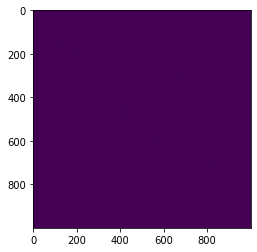

In [ ]:
u = np.array([[.5, -.5, -.5, 490, .5, -.5, 120], [.5, .5, -.5, 340, .5, .5, -110]])
parameters = parameters_determinant(3)
fractal_image(fractal_generator(parameters, 1000, 1000, 10))
parameters.astype(float)
# 1ое предположение: точки все срезаются проверкой границ - Проверено: судя по показаниям shape не похоже, что это оно
# 2ое предположение: что-то не так с конвертером координат

In [ ]:
a = np.array([[1, 2, 3], [3, 4, 5], [6, 7, 8]])
a

array([[1, 2, 3],
       [3, 4, 5],
       [6, 7, 8]])

In [ ]:
idxs = np.array([[1, 2], [2, 0]])
idxs, idxs[:, 0], idxs[:, 1]

(array([[1, 2],
        [2, 0]]), array([1, 2]), array([2, 0]))

In [ ]:
a[idxs[:, 0], idxs[:, 1]]

array([5, 6])

In [ ]:
a[idxs]

Функция генерации фракталов (3я версия - работает плохо)

In [ ]:
# Создание своей фукнции генерации фракталов, на основе того, что есть совсем внизу
def fractal_generator(transformations, height, width, scale, threshold, iterations=1):
  # Определение размера фотки с фракталом
  xOfPhoto = np.linspace(-height / scale, height / scale, height)[None, ...]
  yOfPhoto = np.linspace(-width / scale, width / scale, width)[..., None]
  # Создание матрицы для фото на заполнение параметризированно созданными в определенных местах
  matrixOfPhoto = np.tile(xOfPhoto, (height, 1)) + 1j * np.tile(yOfPhoto, (1, width))
  # Матрица точек, которые надо продолжать изменять и которые нет
  matrixOfPointsToEdit = np.full((width, height), True, dtype=bool)
  iterationForEachPointToStop = np.zeros((width, height))

  for i in range(iterations):
    choiceOfTransformations = np.random.choice(len(transformations), p=transformations[:, 0].astype(float))
    # Коэффиценты для фракталообразования в итеративном использовании формулы
    firstCoefficient = transformations[choiceOfTransformations, 1]
    secondCoefficient = transformations[choiceOfTransformations, 2]
    thirdCoefficient = transformations[choiceOfTransformations, 3]
    # Слагаемые для итеративного вычисления
    firstTerm = matrixOfPhoto[matrixOfPointsToEdit] * matrixOfPhoto[matrixOfPointsToEdit] * matrixOfPhoto[matrixOfPointsToEdit] * firstCoefficient
    secondTerm = matrixOfPhoto[matrixOfPointsToEdit] * secondCoefficient
    thirdTerm = thirdCoefficient
    # Вычисление точек
    matrixOfPhoto[matrixOfPointsToEdit] = firstTerm + secondTerm + thirdTerm
    # Установка того, что после определённого числа в ячейке больше подниматься не будет
    matrixOfPointsToEdit[np.abs(matrixOfPhoto) > threshold] = False
    # Приравнивание итерации к точке, которая на этой итерации заполнилась
    iterationForEachPointToStop[matrixOfPointsToEdit] = i
  return iterationForEachPointToStop

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  if __name__ == '__main__':


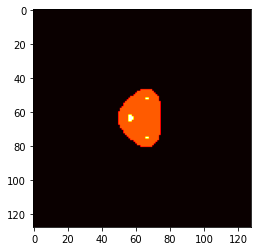

In [ ]:
a = np.array([[.5, -.5 - .5j, -.5 - .5j, 490 + 120j], [.5, .5 + .5j, -.5 + .5j, 340 - 110j]])
N = fractal_generator(parameters_determinant(np.random.choice([1])), 128, 128, 20, 10000, 50000)
plt.imshow(np.flipud(N), cmap='hot')

Функция создания фотки по точкам в уже сгенерированном фрактале (функция растягивания и определения параметров фотки, чтобы всё уместилось и было посередине)

Функция визуализации фрактала (работает с первой версией)

In [ ]:
def fractal_image(points, width, height):
  # Нахождение самой левой, самой правой, Самой низкой, самой высокой точек
  xMin = min(points, key=lambda p:p[0])[0]
  xMax = max(points, key=lambda p:p[0])[0]
  yMin = min(points, key=lambda p:p[1])[1]
  yMax = max(points, key=lambda p:p[1])[1]

  # Создание новой картинки
  image = Image.new('RGB', (width, height))
  # Включение функции рисования
  draw = ImageDraw.Draw(image)

  # Прогон цикла через все точки и применение к ним определенных операций для получения нужного местоположения
  for i in points:
    x = range_converter(i[0], xMin, xMax, 0, width)
    y = height - range_converter(i[1], yMin, yMax, 0, height)
    draw.point((x, y))
  print(points)
  return image


Функция изуализации фрактала (работает с 3ей версией)

In [ ]:
def fractal_image(matrixOfPhoto):
  plt.imshow(matrixOfPhoto)

Функция визуализации фрактала (Должна работать с 2ой версией, но не закончена)

In [ ]:
  def fractal_image(points, width, height):
  # Нахождение самой левой, самой правой, Самой низкой, самой высокой точек
  xMin = torch.min(points[:, 0])
  xMax = torch.max(points[:, 0])
  yMin = torch.min(points[:, 1])
  yMax = torch.max(points[:, 1])

  # Создание новой картинки
  image = Image.new('RGB', (width, height))
  # Включение функции рисования
  draw = ImageDraw.Draw(image)

  # Прогон цикла через все точки и применение к ним определенных операций для получения нужного местоположения
  for i in points:
    x = range_converter(i[0], xMin, xMax, 0, width)
    y = height - range_converter(i[1], yMin, yMax, 0, height)
    draw.point((x, y))
  print(points)
  return image

Попытка соединить и визуализировать всё написанное выше (Работает только с 1ой версией)

In [ ]:

d = {
    "iterations": 28,
    "width": 300,
    "height": 600,
    "transformations": [
        [.01, (0, 0, 0, 0, .16, 0)],
        [.07, (.2, -.26, 0, .23, .22, 1.6)],
        [.07, (-.15, .28, 0, .26, .24, .44)],
        [.85, (.85, .04, 0, -.04, .85, 1.6)]
    ]
}
c = {
    "iterations": 50,
    "width": 600,
    "height": 600,
    "transformations": [
        [.073, (.25, 0, 0, 0, .25, .5)],
        [.927, (.823, -.475, .301, .475, .823, -.172)]
    ]
}

a = {
    "iterations": 50,
    "width": 600,
    "height": 600,
    "transformations": [
        [.5, (-.5, -.5, 490, .5, -.5, 120)],
        [.5, (.5, -.5, 340, .5, .5, -110)]
    ]
}

two = fractal_image(fractal_generator(d['transformations'], 30), 600, 600)
one = fractal_image(fractal_generator(a['transformations'], 30), 600, 600)
b = fractal_image(fractal_generator(c['transformations'], 50), 600, 600)

#Работа с Clip

Подгрузка нейросети из Гитхаба

In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-bpkkdzav
  Running command git clone -q https://github.com/openai/CLIP.git /tmp/pip-req-build-bpkkdzav
     |████████████████████████████████| 64 kB 1.5 MB/s 
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369080 sha256=1122696c3082265e6970ee020a2d4cd6d357c5a9c967b6b510ca2c012a39ac76
  Stored in directory: /tmp/pip-ephem-wheel-cache-9mf5mqlp/wheels/fd/b9/c3/5b4470e35ed76e174bff77c92f91da82098d5e35fd5bc8cdac
  Created wheel for ftfy: filename=ftfy-6.0.3-py3-none-any.whl size=41934 sha256=c98a1789727e7064c90689bdd733f45fbc41facd538f1ff1e85931d8687095de
  Stored in directory: /root/.cache/pip/wheels/19/f5/38/273eb3b5e76dfd850619312f693716ac4518b498f5ffb6f56d
Successfully built clip ftfy


In [ ]:
import torch
from PIL import Image
import clip

In [ ]:
np.shape(b)

torch.Size([1])

Проверка работы нейросети с сгенерированными фракталами

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 143MiB/s]


label image1 probs: 0.031 0.143 0.826
label image2 probs: 0.198 0.024 0.778
label image3 probs: 0.016 0.840 0.144


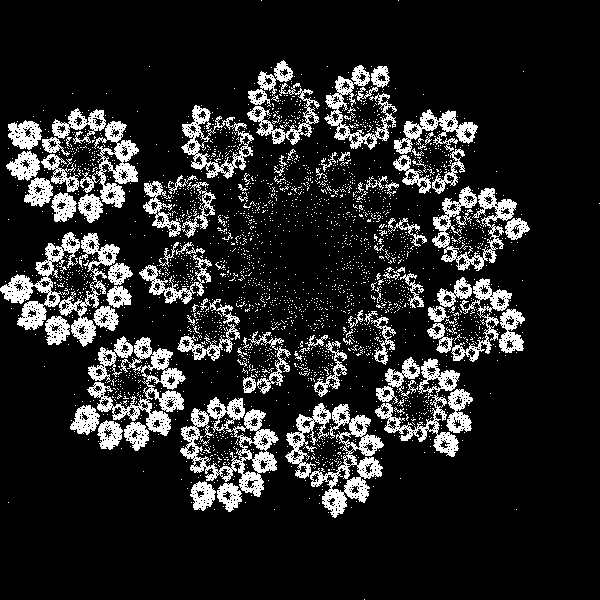

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model-тут метод просто с сервака clip скачивает обученную модель
# preprocess - аллгоритм предобработки картинки перед её подачей в нейросеть
model, preprocess = clip.load('ViT-B/32', device=device)

image1 = preprocess(b).unsqueeze(0).to(device)
image2 = preprocess(one).unsqueeze(0).to(device)
image3 = preprocess(two).unsqueeze(0).to(device)
text = clip.tokenize(['a diagram', 'a spiral', 'a flower']).to(device)

with torch.no_grad():
  imageFeatures1 = model.encode_image(image1)
  textFeatures = model.encode_text(text)

  logitsPerImage, logitsPerText = model(image1, text)
  probs = logitsPerImage.softmax(dim=-1).cpu().numpy()

  print('label image1 probs:', *[f"{prob:.3f}" for prob in probs[0]])

  imageFeatures2 = model.encode_image(image2)

  logitsPerImage, logitsPerText = model(image2, text)
  probs = logitsPerImage.softmax(dim=-1).cpu().numpy()
  print('label image2 probs:', *[f"{prob:.3f}" for prob in probs[0]])

  logitsPerImage, logitsPerText = model(image3, text)
  probs = logitsPerImage.softmax(dim=-1).cpu().numpy()
  print('label image3 probs:', *[f"{prob:.3f}" for prob in probs[0]])

b

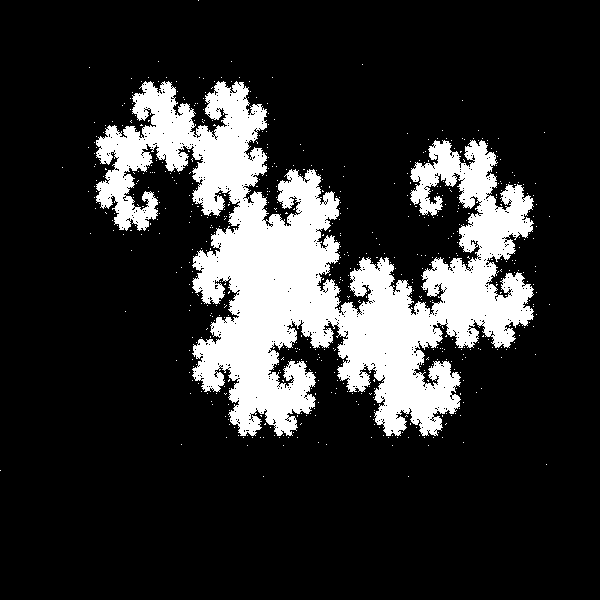

In [ ]:
one

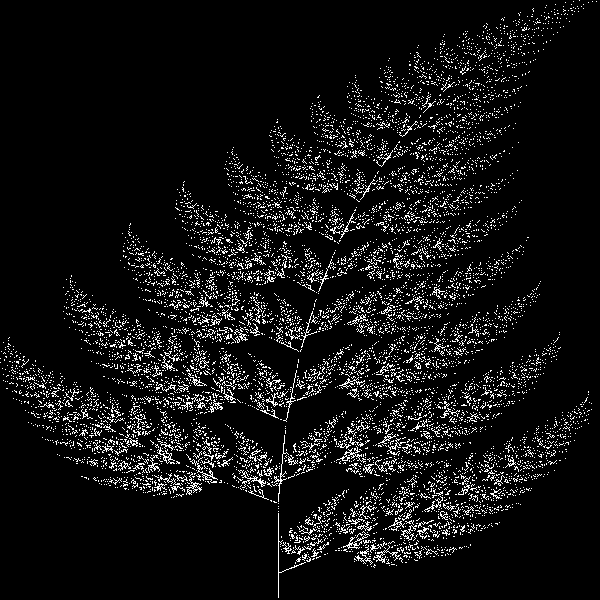

In [ ]:
two

#Проба создать ген. алгоритм

In [ ]:
def generate_first_population(numberOfParameters, sizeOfPopulation, minOfParameter, maxOfParameter):
  populationWithParameters = np.zeros((sizeOfPopulation, numberOfParameters))
  for i in range(sizeOfPopulation):
    for j in range(numberOfParameters):
      populationWithParameters[i, j] = np.random.uniform(minOfParameter, maxOfParameter)

In [ ]:
pointsList = np.random.randn(100, 2)
straight = np.arange(100)
x = pointsList[:, 0] + 2 * straight
y = pointsList[:, 1] + - 4 * straight + 20

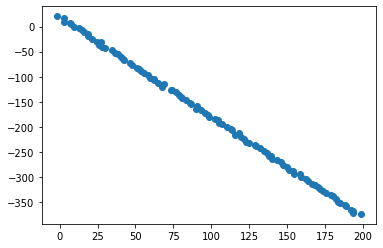

In [ ]:
plt.scatter(x, y)

In [ ]:
w0 = np.random.randn(100)
w1 = np.random.randn(100)

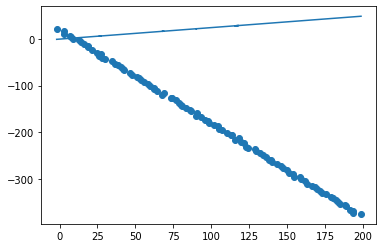

In [ ]:
plt.scatter(x, y)
plt.plot(x, (x*w0[0])+w1[5])

In [ ]:
def MSE(Ypred, Ytrue):
  return np.mean((Ypred - Ytrue)**2)

In [ ]:
a = np.ones(100)
for i in range(100):
  a[i] = MSE((x*w0[i])+w1[i], y)

In [ ]:
a.argsort()

array([[0, 1, 2],
       [0, 1, 2],
       [0, 1, 2]])

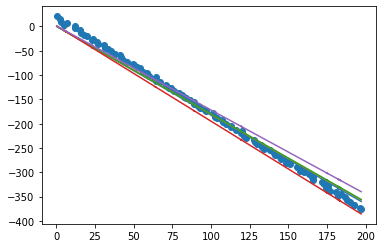

In [ ]:
bestW0 = w0[a.argsort()[:int(100*0.05)]]
bestW1 = w1[a.argsort()[:int(100*0.05)]]
plt.scatter(x, y)
for i in range(len(bestW0)):
  plt.plot(x, (x*bestW0[i])+bestW1[i])

In [ ]:
def new_population(bestOfPreviousPopulation, sizeOfPopulation, numberOfParameters):
  numberOfNewForOneBest = sizeOfPopulation // len(bestOfPreviousPopulation)
  newPopulation = np.zeros(sizeOfPopulation, numberOfParameters)
  for i in range(sizeOfPopulation):
    for i in range(bestOfPreviousPopulation):
      if


SyntaxError: ignored

#Работа с генетический алгоритмом

Функция рандомного создания параметров

In [ ]:
# Можно ли здесь как-нибудь без циклов сначала для каждой трансформации, для каждого x и y у них рандомно определить коэффиценты
# (если что, то покажи план на листочке по написанию этой функции)
# Надо ли здесь ставить аргумент количества генерируемых фракталов (мне кажется нет) или потом просто в цикле их поотдельности создавать будем

def parameters_determinant(numberOfTransformations):
  parameters = np.zeros((numberOfTransformations, 7)) #Создание матрицы для параметров
  parameters[:, 0] = np.random.dirichlet(np.random.randint(1, 10, numberOfTransformations)) # Внесение в вероятностей в матрицу для каждой из трансформаций
  parameters[:, 1:3] = np.random.uniform(-5, 5, (numberOfTransformations, 2)) # Создание коэффицентов A и B для x
  parameters[:, [3, 6]] = np.random.uniform(-100, 100, (numberOfTransformations, 2)) # Создание коэффицента C для x и y
  parameters[:, 4:6] = np.random.uniform(-5, 5, (numberOfTransformations, 2)) # Создание коэффицентов A и B для y
  return parameters

Тестовая 3я версия функции генерации (создает только julia set)

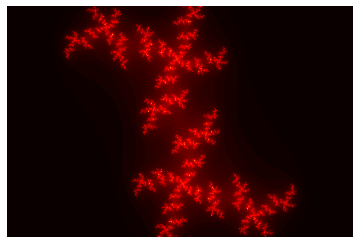

In [ ]:
# https://tomroelandts.com/articles/how-to-compute-colorful-fractals-using-numpy-and-matplotlib - Сайт с объяснением
m = 480
n = 320

s = 300
x = np.linspace(-m / s, m / s, num=m).reshape((1, m))
y = np.linspace(-n / s, n / s, num=n).reshape((n, 1))
Z = np.tile(x, (n, 1)) + 1j * np.tile(y, (1, m))
#for i, k in zip(np.linspace(-1, 1, num=100), np.linspace(-1, 1, 100)):
C = np.full((n, m), 0.31 + 0.61j)
M = np.full((n, m), True, dtype=bool)
N = np.zeros((n, m))
for i in range(256):
  Z[M] = Z[M] * Z[M] + C[M]
  M[np.abs(Z) > 2] = False
  N[M] = i
fig = plt.figure()
fig.set_size_inches(m / 100, n / 100)
ax = fig.add_axes([0, 0, 1, 1], frameon=False, aspect=1)
ax.set_xticks([])
ax.set_yticks([])
plt.imshow(np.flipud(N), cmap='hot')

# А если добавить цвет к картинкам, то разве не будет Clip путаться?
# Или может лучше сделать пока что без цветов, пока они на обработке в сетке, а выходную раскасить?

In [ ]:
def calc(c1, c2):
  x = y = 0
  for i in range(10):
    ynext = x*x

In [ ]:
pixelScale = 200
width = 3
height = 3
xStart = -2
yStart = -1.5

imageWidth = int(pixelScale * width)
imageHeight = int(pixelScale * height)

def calc(c1, c2):
  x = y = 0
  for i in range(1000):
    x, y = x*x - y*y + c1, 2*x*y + c2
    if x*x + y*y > 4:
      return i+1
  return 0

array = np.zeros((imageHeight, imageWidth), dtype=int)

for i in range(imageWidth):
  c1 = xStart + i / pixelScale
  for j in range(imageHeight):
    c2 = yStart + j / pixelScale
    v = calc(c1, c2)
    if v:
      array[j, i] = 1

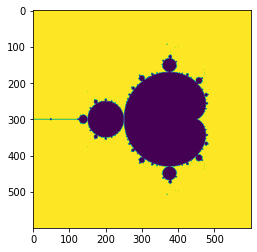

In [ ]:
plt.imshow(array)

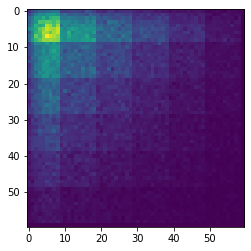

In [ ]:
photo = np.zeros((60, 60))
a = np.array([1, 2, 3, 4, 5, 6])
for i in range(100000):
  x = np.random.choice(a)
  y = np.random.choice(a)
  coefficientx = np.random.uniform(1, 10)
  coefficienty = np.random.uniform(1, 10)
  photo[int((y*coefficienty)-1), int((x*coefficientx)-1)] += 1
  #photo[int(-(y*coefficienty)-1), int(-(x*coefficientx)-1)] += 1
plt.imshow(photo)